# Mini-Project 1 — Mandelbrot Set
**Course:** Numerical Scientific Computing  
**Program:** M.Sc. Computer Engineering  
**University:** Aalborg University  

## Objective
The goal of this mini-project is to implement and compare three versions of the Mandelbrot set computation:

1. A naïve pure Python implementation using nested loops  
2. A NumPy-based vectorized implementation  
3. A Numba-optimized implementation  

In this notebook I am to implement the Mandelbrot set in three different ways, and then, I am going to do the benchmarks to see the differences between each other.

## Problem description
This project is going to have 3 different checkpoints, in the first one we are going to develop a naive implementation using nested loops with python, in the second one we are going to develope a numpy vectorized grid, and last but not least a numba opmitized version.

With all three different implementations we are going to mesure the performance and the scaling analisys.



For this first implementation, lets establish the necessary milestones to successfylly develop the code.
 

Import the libraries

In [68]:
import time
import math
import numpy as np
import matplotlib.pyplot as plt
    

Define the region (x_min,x_max,y_min,y_max, width, height, max_iterations and escape_radius)

In [69]:
# Region in the complex plane
X_MIN, X_MAX = -2.0, 1.0
Y_MIN, Y_MAX = -1.5, 1.5

# Default parameters
DEFAULT_WIDTH = 400
DEFAULT_HEIGHT = 400
DEFAULT_MAX_ITER = 100
ESCAPE_RADIUS = 2.0

Define a general function to plot the results of the mandelbrot set

In [70]:
def plot_mandelbrot(data, title="Mandelbrot Set"):
    plt.figure(figsize=(8, 8))
    plt.imshow(
        data,
        extent=[X_MIN, X_MAX, Y_MIN, Y_MAX],
        origin="lower",
        cmap="hot"
    )
    plt.colorbar(label="Normalized escape value")
    plt.xlabel("Real part")
    plt.ylabel("Imaginary part")
    plt.title(title)
    plt.show()



Develop the Naive implementation



## 1. Naïve implementation

This implementation uses pure Python and nested loops.
For each pixel in the image, a complex number \( c \) is created, and the Mandelbrot iteration is computed step by step until escape or until the maximum number of iterations is reached.

In [71]:
def mandelbrot_naive(width, height, max_iter):
    result = np.zeros((height, width), dtype=np.float64) #Create a 2D array to hold the escape values

    for row in range(height):
        for col in range(width):
            # Map pixel -> complex plane
            x = X_MIN + (col / (width - 1)) * (X_MAX - X_MIN) #Map pixel column to real part
            y = Y_MIN + (row / (height - 1)) * (Y_MAX - Y_MIN) #Map pixel row to imaginary part

            c = complex(x, y)  #Create complex number for the current pixel
            z = 0j

            escape_iter = max_iter #Initialize escape iteration count to max_iter (assume it does not escape)

            for n in range(max_iter):
                z = z * z + c #Iterate the Mandelbrot function
                if abs(z) > ESCAPE_RADIUS:#Check if the magnitude of z exceeds the escape radius
                    escape_iter = n + 1
                    break

            result[row, col] = escape_iter / max_iter #Normalize escape iteration count to [0, 1]

    return result

After running the code, plot the Naive Mandelbrot

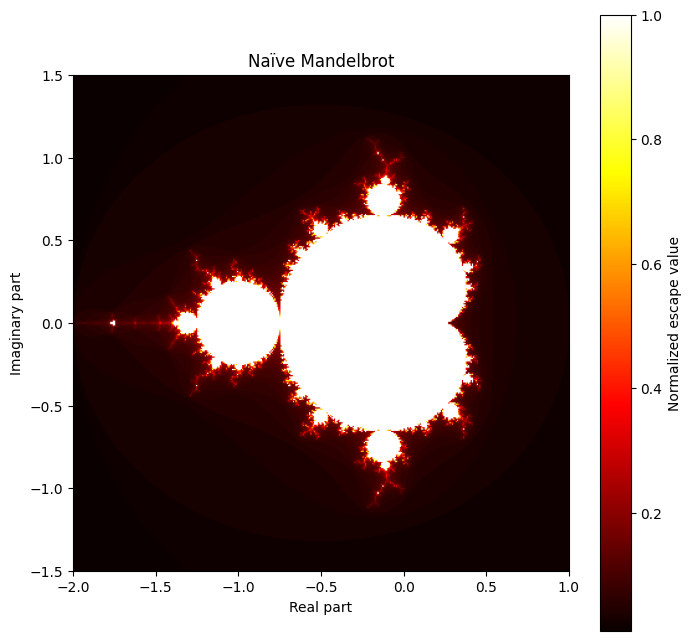

In [72]:
mandelbrot_1=mandelbrot_naive(DEFAULT_WIDTH, DEFAULT_HEIGHT, DEFAULT_MAX_ITER)
plot_mandelbrot(mandelbrot_1, title="Naïve Mandelbrot")